# Homework #1
## Introduction to supervised learning

This colaboratory contains Homework #1 of the Machine Learning course. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

**NB! Links to your colaboratory will not be accepted as a solution!**

## Submission's rules:

1. Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in the same IPYNB file.

##List of Homework's exercises:
1. [EX1](#scrollTo=tz9XASPxeqDC) - 3 points
2. [EX2](#scrollTo=BGVGqZGpxmzQ&uniqifier=1#) - 2 points
4. [EX3](#scrollTo=7p4GMeGK-QGL&uniqifier=1) - 1 points
5. [EX4](#scrollTo=anNhQy0AlLD6&line=1&uniqifier=1) - 4 points
6. [Bonus 1](#scrollTo=_2T9ydozzcb-&uniqifier=1) - 2 points
7. [Bonus 2](#scrollTo=UkOtofaRjH8P&uniqifier=1) - up to 5 points
8. [Bonus 3](#scrollTo=hDIQVrR-YiaL&line=1&uniqifier=1) - up to 3 points


### Homework setup:
Here we will load necessary libraries (NumPy and Pandas) and MNIST dataset

In [1]:
import numpy as np # for matrix stuff
import pandas as pd # to work with datasets
import matplotlib.pyplot as plt # subjectively ugly plotting here
from seaborn import countplot # a bit less ugly plotting

# Getting MNIST one more time
from tensorflow.keras.datasets import mnist
(images, labels),(_, _) = mnist.load_data()
images = images / 255 # normalising images

print(f"images are of shape: {images.shape} and labels: {labels.shape}")

# Subsample the images
train_images = images[:2000]
train_labels = labels[:2000]

test_images = images[2000:3000]
test_labels = labels[2000:3000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
images are of shape: (60000, 28, 28) and labels: (60000,)


## Homework exercise 1 (3 points): KNN
<font color='red'>One very popular variation of Nearest Neighbour is K-nearest neighbour. In this algorithm a label for a new instance is chosen by majority vote by **`k`** of its nearest neighbors.

<font color='red'>The actual algorithm is not very different from vanila nearest neighbour:

1. <font color='red'> Compute distances to all points in the dataset
2. <font color='red'> Find the **`k`** closest points (you may consider using `np.argsort` function)
3. <font color='red'> Report the most popular label from these **`k`**. (maybe `np.bincount` can help)

<font color='red'>**(Homework exercise 1- a)** Implement the aformentioned algorithm in the cell below (2.0 points)</font>

In [2]:
def dist(img1, img2):
  ##### YOUR CODE STARTS #####
  return np.linalg.norm(img1-img2)
  ##### YOUR CODE ENDS #####

def classify_knn(image, k, train_images, train_labels):
  ##### YOUR CODE STARTS #####
  all_distances = np.array([dist(image, train_img) for train_img in train_images])
  knn = np.argsort(all_distances)[:k]
  counts = train_labels[knn]
  prediction = np.bincount(counts).argmax()
  ##### YOUR CODE ENDS #####
  return prediction

Test the function on two first images from `test_images`:

In [3]:
##### YOUR CODE STARTS #####
print(f"Predicted class for the first image is {classify_knn(test_images[0], 3, train_images, train_labels)} and the true label is {test_labels[0]}")
print(f"Predicted class for the second image is {classify_knn(test_images[1], 3, train_images, train_labels)} and the true label is {test_labels[1]}")
##### YOUR CODE ENDS #####

Predicted class for the first image is 6 and the true label is 5
Predicted class for the second image is 8 and the true label is 8


<font color='red'>**(Homework exercise 1- b)** Create a new function `classify_knn_print` from `classify_knn` that you have just implemented in **1- a**  by adding a print statement that outputs labels of K nearest neighbours. Report 10 nearest neighbours for the first two images from the `test_images`. Why do you think these digits were among the closest neighbours? (0.5 points) </font>

In [4]:
def classify_knn_print(image, k, train_images, train_labels):
  ##### YOUR CODE STARTS #####
  all_distances = np.array([dist(image, train_img) for train_img in train_images])
  knn = np.argsort(all_distances)[:k]
  counts = train_labels[knn]
  print(f"Labels of the {k} nearest neighbors: {knn}")
  prediction = np.bincount(counts).argmax()
  ##### YOUR CODE ENDS #####
  return prediction

In [5]:
##### YOUR CODE STARTS #####
print(f"Predicted class for the first image is {classify_knn_print(test_images[0], 10, train_images, train_labels)} and the true label is {test_labels[0]}")
print(f"Predicted class for the second image is {classify_knn_print(test_images[1], 10, train_images, train_labels)} and the true label is {test_labels[1]}")
##### YOUR CODE ENDS #####

Labels of the 10 nearest neighbors: [ 578 1957 1328  782 1582 1898  940  100 1882 1257]
Predicted class for the first image is 6 and the true label is 5
Labels of the 10 nearest neighbors: [1943  777   97   41  125  823 1101 1657  571 1749]
Predicted class for the second image is 8 and the true label is 8


Answer to (b):

These digits were among the closest neighbors due to their shape similarity: first image 5 → 6 has nearest neighbors include 6s, 9s, and some 5s, as their curved structures resemble each other. Some 5s with rounded strokes may look like 6s. Second image 8 → 8 was correctly classified, all nearest neighbors are 8s, indicating that the digit 8 has a distinct and consistent shape. KNN selects neighbors based on pixel similarity, so small handwriting variations influence which digits are considered closest.

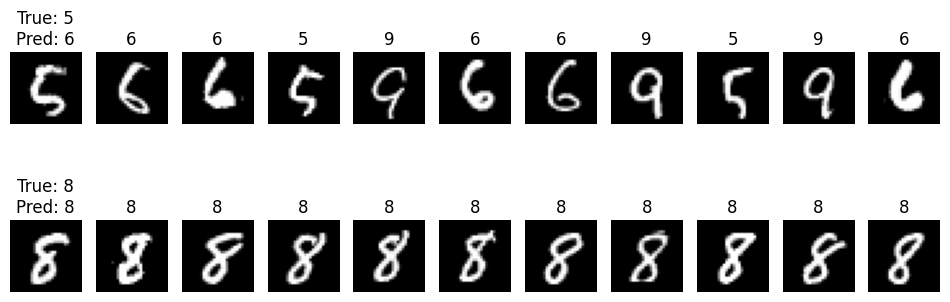

In [11]:
neighbors_1 = [578, 1957, 1328, 782, 1582, 1898, 940, 100, 1882, 1257]
labels_1 = train_labels[neighbors_1]
pred_1 = 6
true_label_1 = test_labels[0]

neighbors_2 = [1943, 777, 97, 41, 125, 823, 1101, 1657, 571, 1749]
labels_2 = train_labels[neighbors_2]
pred_2 = 8
true_label_2 = test_labels[1]

fig, axs = plt.subplots(2, 11, figsize=(12, 4))
for i, (image, neighbors, labels, pred, true_label) in enumerate(
        [(test_images[0], neighbors_1, labels_1, pred_1, true_label_1),
         (test_images[1], neighbors_2, labels_2, pred_2, true_label_2)]):
    axs[i, 0].imshow(image, cmap='gray')
    axs[i, 0].set_title(f"True: {true_label}\nPred: {pred}")
    axs[i, 0].axis('off')
    for j in range(10):
        axs[i, j+1].imshow(train_images[neighbors[j]], cmap='gray')
        axs[i, j+1].set_title(f"{labels[j]}")
        axs[i, j+1].axis('off')
plt.show()

<font color='red'>**(Homework exercise 1- c)** Classify all test images using `classify_knn` (**please, do not use print version**) and store them into a separate variable `test_predicted`, choose `k` = 5. Compute accuracy of your KNN model. (0.5 points) </font>

In [7]:
##### YOUR CODE STARTS #####
test_predicted = np.array([classify_knn(img, 5, train_images, train_labels) for img in test_images])
n_correct = np.sum(test_predicted == test_labels)
knn_accuracy = n_correct / len(test_labels)
##### YOUR CODE ENDS ##### (please do not delete this line)
print(f"Final accuracy of our nearest neighbor classifier is {knn_accuracy}. Not bad!")

Final accuracy of our nearest neighbor classifier is 0.912. Not bad!


## Homework exercise 2 (2 points): exploring misclassified examples
<font color='red'>**(Homework exercise 2- a)** Modify the visualisation code that we used during the practice session to visualise a grid of example images from different classes. Now, instead of random examples from each class, visualise misclassified examples from each class. For example, in the first column visualise images that had true label `0` but were classified as something else, in the second column, show examples of images that had label `1` but were misclassified into another class and so on. Add a title to each small image, in the following format `true_label, predicted_label` e.g. "0, 6" - image of class 0 was classified as 6. (1.5 points)

**NB! you need a variable `test_predicted` to exist from the previous exercise to complete this exericse.** </font>

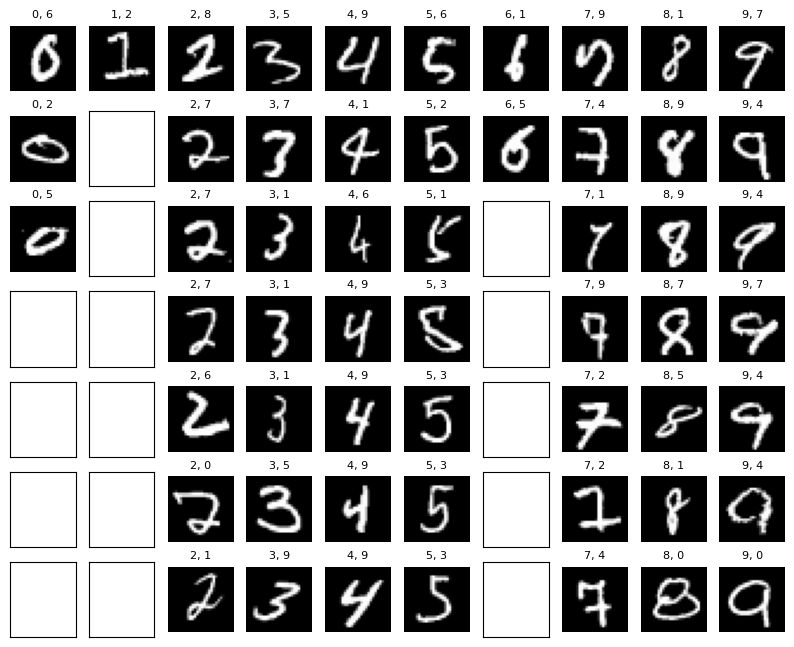

In [8]:
num_classes = 10
samples_per_class = 7 # Number of images from each class we want to see
fig, axs = plt.subplots(samples_per_class, num_classes, figsize=(10.0, 8.0))
for i in range(num_classes):
    ##### YOUR CODE STARTS #####
    misclassified_ids = np.where((test_labels == i) & (test_predicted != i))[0]
    misclassified_samples = misclassified_ids[:samples_per_class]
    for j, idx in enumerate(misclassified_samples):
        axs[j, i].imshow(test_images[idx], cmap='gray')
        axs[j, i].set_title(f"{test_labels[idx]}, {test_predicted[idx]}", fontsize=8)
        axs[j, i].axis('off')
    ##### YOUR CODE ENDS #####
plt.setp(axs,xticks=[],yticks=[]) # set all axes off
plt.show()

<font color='red'>**(Homework exercise 2- b)** Take a careful look at the resulting figure. Are all classes equally missclassified? Why? Are there any classes that KNN confuses more often, why? (0.5 points) </font>

Answer to (b):

Not all classes are equally misclassified. Digits 4, 7, 9, and 2 tend to be misclassified more often due to their similar shapes. For example, 4 is often confused with 9, and 7 with 9 or 4 because of their handwritten variations. On the other hand, digits like 0, 1, and 6 have fewer misclassifications as their shapes are more distinct.

The KNN model struggles with digits that share visual similarities, especially in noisy or unclear handwriting. A more advanced approach, such as a CNN, would likely improve accuracy.

## Preparation for homework exercises 3 and 4
Next we will work with real-world dataset collected from taxis operating in New York City

In [1]:
# Code to read csv file into Colaboratory:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

link = 'https://drive.google.com/file/d/1XKhfq4WFHlTrvag48cD3VDJGfykYUJ-s' # The shareable link

In [2]:
downloaded = drive.CreateFile({'id':'1XKhfq4WFHlTrvag48cD3VDJGfykYUJ-s'})
downloaded.GetContentFile('nyc_data_2.zip')

# After archive has been downloaded
# unzip it
!unzip nyc_data_2.zip

Archive:  nyc_data_2.zip
  inflating: train_2M.csv            
  inflating: test.csv                
  inflating: model.pickle            
  inflating: sample_submission.csv   


* `train_2M.csv` contains 2 million observations from NYC dataset (6 independent variables and fare_amount that we need to predict).
* `test.csv` contains new observations, for which we have to estimate `fare_amount` based on train data.
* `sample_submission.csv` - a sample submission file in the correct format (columns `key` and `fare_amount`). Every row in this file matches every row in `test.csv`.
* `model.pickle` - file that contains trained model saved as a pickle (we are going to deal with it later)

## Homework exercise 3 (1 point): read and explore `model.pickle`

<font color='red'> **(Homework exercise 3- a)** In this exercise we will use module `pickle` that let's you store your machine learning models as files. Later you can share these models (aka pickles) with your colleagues or your future self.

<font color='red'> In this exercise, use `pickle` module to read in `model.pickle` file that you have downloaded from `nyc_data_2.zip` using `pickle.load()` function. For details consult the documentation page: https://docs.python.org/3/library/pickle.html. (0.5 points)

In [3]:
import pickle
import os

##### YOUR CODE STARTS #####
filename = "model.pickle"
with open(filename, 'rb') as file:
    model = pickle.load(file)
##### YOUR CODE ENDS #####

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.0.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


<font color='red'> **(Homework exercise 3- b)** next, explore the object using function `dir` and answer the following questions:
* <font color='red'> Which model was saved into this object?
* <font color='red'> How many coefficients it has and what are their values?
* <font color='red'>Can you find out which features have been used for training?

<font color='red'>(0.5 points)


Answers to (b):

In [15]:
print("Attributes of the loaded model:", dir(model))
print("Number of coefficients:", len(model.coef_))
print("Coefficient values:", model.coef_)
print("Features used for training:", model.feature_names_in_)

Attributes of the loaded model: ['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_decision_function', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_residues', '_set_intercept', '_validate_data', '_validate_params', 'coef_', 'copy_X', 'feature_names_in_

1. The saved model is a linear regression model since it has coefficients `coef_` and an intercept `intercept_`.
2. It has one set of coefficients with values `[146.11, 89.26, 0.052]`, indicating the model uses three features.
3. These three features are: `abs_diff_longitude`, `abs_diff_latitude`, `passenger_count`. They suggest that the mpdel predictions are based on the distance and the number of passengers.

### Setting up Kaggle

You need to have an account on Kaggle.com, before you proceed to the last exercise. When in your account, you need to download your API Token from kaggle. It's very easy:
1. Click on your profile icon
2. Go to **Account**
3. In **API** you press **Create new API token**

Now we load the file **kaggle.json** that you have downloaded, into this notebook:

In [4]:
from google.colab import files

files.upload();

Saving kaggle.json to kaggle.json


The next cell moves the file into a separate folder, sets secure access for it and configures your Kaggle profile for this notebook.

In [5]:
import json

!mkdir /root/.kaggle/
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v{/content}

- path is now set to: {/content}


In order to sign up for a NYC Taxi competition you need to accept the rules by cliking on "Late submission" button in the upper right corner: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction

Make a test submission to ensure that the submission mechanism works

In [18]:
!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f sample_submission.csv -m "Sample submission test"

100% 335k/335k [00:00<00:00, 876kB/s]
Successfully submitted to New York City Taxi Fare Prediction

Now you can check `My submissions` tab on the website: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction/submissions

## Read in the NYC data and perform basic preprocessing

In [8]:
%%time

# note that we use only 1M out of 2M records
train =  pd.read_csv('train_2M.csv', parse_dates=["pickup_datetime"], nrows = 1_000_000) # the first row will automatically be interpreted as a header

# functions that add two new features abs_diff_longitude and abs_diff_latitude
def add_travel_vector_features(df):
    df['abs_diff_longitude'] = (df.dropoff_longitude - df.pickup_longitude).abs()
    df['abs_diff_latitude'] = (df.dropoff_latitude - df.pickup_latitude).abs()

# adding two new features to train
add_travel_vector_features(train)

# reading in test and adding two new features to test
test = pd.read_csv('test.csv')
add_travel_vector_features(test)

# removing not available values and outliers
train = train.dropna(how = 'any', axis = 'rows')
train = train[(train.abs_diff_longitude < 5.0) & (train.abs_diff_latitude < 5.0)]

X = train.drop('fare_amount', axis=1)
y = train['fare_amount']

CPU times: user 1.57 s, sys: 203 ms, total: 1.77 s
Wall time: 1.78 s


## Homework exercise 4 (4 points): K-fold cross-validation algorithm
<font color='red'> In the classroom we were cheating on our validation data when we hand-picked the depth of the decision tree (as we used validation data multiple times). The honest and better way of finding a good hyperparameter (depth of the tree) is a **K-fold cross-validation algorithm**.


<font color='red'> **(Homework exercise 4- a)** Implement the K-fold cross-validation algorithm using lecture slides and hints in comments. Use `abs_diff_longitude` and `abs_diff_latitude` featues.  (3.5 points) </font>

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Fixing randomness, please do not change this line.
np.random.seed(1111)

X = train[['abs_diff_longitude', 'abs_diff_latitude']]
max_depths = [1, 2, 5, 8, 9, 10, 11, 12, 13, 15, 20]
depth_RMSEs = list()

# 4-fold cross validation
for param in max_depths:
  print(f'Calculating RMSE for tree with a depth {param}...')
  ##### YOUR CODE STARTS #####
  # number of folds
  n_folds = 4

  # create a vector of fold indices
  # with length of this vector equal to number of rows in training data
  # you can use np.concatenate and np.repeat functions
  folds_indx = np.concatenate([np.repeat(i, len(X) // n_folds) for i in range(n_folds)])
  folds_indx = np.pad(folds_indx, (0, len(X) - len(folds_indx)), mode='constant', constant_values=n_folds-1)

  # for dataset with 8 entries you should get:
  # the following vector[0, 0, 1, 1, 2, 2, 3, 3]
  # chunks can be unequal if the number of rows is not divisible by 4

  # randomly shuffle the obtained indices
  np.random.shuffle(folds_indx)

  # initialise variable that will hold RMSEs for each fold
  fold_RMSEs = np.zeros(n_folds)
  for fold_indx in np.arange(n_folds):

    # split data into train_X, train_y and val_X, val_y depending on the fold
    # use previously generated folds_indx to fetch the right rows
    train_X = X[folds_indx != fold_indx]
    train_y = y[folds_indx != fold_indx]
    val_X = X[folds_indx == fold_indx]
    val_y = y[folds_indx == fold_indx]

    # a few tests that must pass to make sure you are doing the right thing
    # please, do not delete these lines
    assert len(train_X) + len(val_X) == len(X), "Train and validation sets combined should be equal to the size of the original dataset"
    assert len(train_X) > len(val_X), "Train set should be larger than validation set (at least three times)"
    assert len(train_X) == 748518 or len(train_X) == 748519, "Train set should be of size 748518 or 748519"

    # train the decision tree with max_depth = param
    dtr = DecisionTreeRegressor(max_depth=param)

    # fit the decision tree on training data
    dtr.fit(train_X, train_y)

    # predict validation data
    val_predictions = dtr.predict(val_X)

    # calculate RMSE on validation for this fold
    fold_RMSEs[fold_indx] = np.sqrt(mean_squared_error(val_y, val_predictions))
  ##### YOUR CODE ENDS #####
  print(f'Average validation RMSE for {param} of trees is {np.mean(fold_RMSEs)}')
  depth_RMSEs.append(np.mean(fold_RMSEs))

Calculating RMSE for tree with a depth 1...
Average validation RMSE for 1 of trees is 7.1861942974423725
Calculating RMSE for tree with a depth 2...
Average validation RMSE for 2 of trees is 6.031533762543336
Calculating RMSE for tree with a depth 5...
Average validation RMSE for 5 of trees is 5.256523087177173
Calculating RMSE for tree with a depth 8...
Average validation RMSE for 8 of trees is 5.065691014021884
Calculating RMSE for tree with a depth 9...
Average validation RMSE for 9 of trees is 5.068076167992335
Calculating RMSE for tree with a depth 10...
Average validation RMSE for 10 of trees is 5.088560544396724
Calculating RMSE for tree with a depth 11...
Average validation RMSE for 11 of trees is 5.121887863565703
Calculating RMSE for tree with a depth 12...
Average validation RMSE for 12 of trees is 5.217585294978854
Calculating RMSE for tree with a depth 13...
Average validation RMSE for 13 of trees is 5.222605363851282
Calculating RMSE for tree with a depth 15...
Average va

<font color='red'> In the cell below, plot the resulting RMSEs for each max depth as a **lineplot**. Report the most optimal depth of the decision tree.

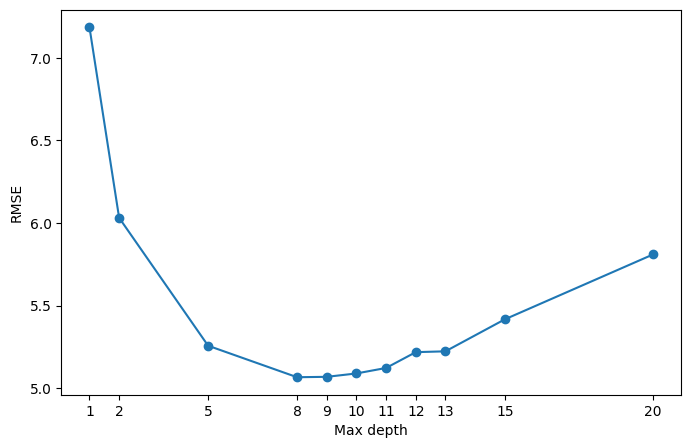

In [24]:
##### YOUR CODE STARTS #####
plt.figure(figsize=(8, 5))
plt.plot(max_depths, depth_RMSEs, marker='o')
plt.xticks(max_depths)
##### YOUR CODE ENDS #####
plt.xticks(max_depths)
plt.xlabel("Max depth")
plt.ylabel("RMSE")
plt.show()

According to the above figure, the most optimal decision tree depth is 8.

<font color='red'> **(Homework exercise 4- b)** Based on above results train the `DecisionTreeRegressor` on the entire training data. Use **the optimal number of trees** that you reported in **4 -a**. Predict the test set and submit the results to Kaggle. Check your results online and print out your new leaderboard score, which should be smaller than 4.02083. (0.5 points) </font>

In [25]:
##### YOUR CODE STARTS #####
optimal_depth = 8

final_model = DecisionTreeRegressor(max_depth=optimal_depth)
final_model.fit(X, y)

test = pd.read_csv('test.csv')
add_travel_vector_features(test)
test_X = test[['abs_diff_longitude', 'abs_diff_latitude']]
test_predictions = final_model.predict(test_X)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_predictions
})
submission.to_csv('submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission.csv -m "Final Decision Tree model"

100% 454k/454k [00:00<00:00, 1.16MB/s]
Successfully submitted to New York City Taxi Fare Prediction

In [26]:
# just copy paste your new score below:
print(f"My new score is {4.00653}")
##### YOUR CODE ENDS #####

My new score is 4.00653


# Bonus exercises
**NB, these are optional exercises! These will be graded more strictly, hence you really need to impress with high quality of the solution to earn points. Add elaborate explanations and cool visuals.**

## Bonus exercise 1 (2 bonus points):

<font color='red'> Visualising misclassified examples can help to debug the classification algorithm. But misclassified examples may have different probabilities. In this bonus exercise (optional) try modifying code we have written for the homework exercise 2 so that title now would include probability of a true class and of a wrong class. You would probably need to change the code of `classify_knn` function. Describe the results. </font>

## Bonus exercise 2 (up to 5 points): the grand challenge
<font color='red'> Try to get into top 300 places on public leaderboard (RMSE < 3.04) using different ML algorithms with different parameters, more features, more data, better preprocessing. Here are some ideas for improvement:
* Use more data (we only took 1M out of 2M, there are 53M more on the website)
* Do more preprocessing (remember negative prices or unrealistic numbers of passengers?)
* Use more/better features (e.g. euclidean distance, or google what is haversine distance)
* Use some other regression algorithm (e.g. look into RandomForestRegressor from sklearn.ensemble)
* Tune parameters of these algorithms
* Try something else!
</font>

<font color='red'>You should make a small post here with code and elaborate explanations of what you have tried (do it even you did not manage to break into top 300). **Report your final leaderboard rank**. Number of points would depend on quality of your explanations and the resulting rank.</font>


In [18]:
# Hint:
R = 6378

def haversine_distance(lon1, lon2, lat1, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)

    All args must be of equal length.

    source: https://stackoverflow.com/a/29546836

    """
    # Convert latitude and longitude to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # Find the differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Apply the formula
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    # Calculate the angle (in radians)
    c = 2 * np.arcsin(np.sqrt(a))
    # Convert to kilometers
    km = R * c

    return km

1. Trying RandomForest with different params of tree

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

train = pd.read_csv('train_2M.csv', parse_dates=["pickup_datetime"], nrows=2_000_000)

def add_travel_vector_features(df):
  df['abs_diff_longitude'] = (df.dropoff_longitude - df.pickup_longitude).abs()
  df['abs_diff_latitude'] = (df.dropoff_latitude - df.pickup_latitude).abs()
  df['euclidean_distance'] = np.sqrt(df['abs_diff_longitude'] ** 2 + df['abs_diff_latitude'] ** 2)
  df['haversine_distance'] = haversine_distance(df['pickup_longitude'], df['dropoff_longitude'],
                                                df['pickup_latitude'], df['dropoff_latitude'])

add_travel_vector_features(train)
train = train.dropna(how='any', axis='rows')
train = train[(train.abs_diff_longitude < 5.0) & (train.abs_diff_latitude < 5.0)]

X = train[['abs_diff_longitude', 'abs_diff_latitude', 'euclidean_distance', 'haversine_distance']]
y = train['fare_amount']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1111)

np.random.seed(1111)

hyperparams = [
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 12},
    {'n_estimators': 150, 'max_depth': 15},
    {'n_estimators': 200, 'max_depth': 18}
]

results = []
for params in hyperparams:
  print(f"Training RandomForest with {params}")
  model = RandomForestRegressor(n_estimators=params['n_estimators'], max_depth=params['max_depth'],
                                random_state=1111, n_jobs=-1)
  model.fit(X_train, y_train)
  val_predictions = model.predict(X_val)
  rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
  print(f"RMSE: {rmse}")
  results.append((params, rmse))

Training RandomForest with {'n_estimators': 50, 'max_depth': 10}
RMSE: 4.752032365964396
Training RandomForest with {'n_estimators': 100, 'max_depth': 12}
RMSE: 4.753919845331944
Training RandomForest with {'n_estimators': 150, 'max_depth': 15}
RMSE: 4.767984398362749
Training RandomForest with {'n_estimators': 200, 'max_depth': 18}


KeyboardInterrupt: 

I decided to stop training because increasing the number of trees and depth beyond max_depth=10, n_estimators=50 did not significantly improve RMSE. In fact, the RMSE slightly worsened. This indicates that a deeper and more complex model does not necessarily improve performance and might lead to overfitting. Instead, let's focus on optimizing a smaller model, adding new features, and refining data preprocessing.

In [16]:
from sklearn.model_selection import KFold

def add_features(df):
  df['abs_diff_longitude'] = (df.dropoff_longitude - df.pickup_longitude).abs()
  df['abs_diff_latitude'] = (df.dropoff_latitude - df.pickup_latitude).abs()
  df['haversine_distance'] = haversine_distance(df['pickup_longitude'], df['dropoff_longitude'],
                                                df['pickup_latitude'], df['dropoff_latitude'])
  df['hour_of_day'] = df['pickup_datetime'].dt.hour
  df['is_night_ride'] = ((df['hour_of_day'] < 6) | (df['hour_of_day'] > 22)).astype(int)

add_features(train)
train = train.dropna(how='any', axis='rows')
train = train[(train.abs_diff_longitude < 5.0) & (train.abs_diff_latitude < 5.0)]

features = ['abs_diff_longitude', 'abs_diff_latitude', 'haversine_distance', 'hour_of_day', 'is_night_ride']
X = train[features]
y = train['fare_amount']

np.random.seed(1111)

kf = KFold(n_splits=5, shuffle=True, random_state=1111)

n_estimators_options = [30, 40, 50, 60]
fold_rmse_results = {}

for n_estimators in n_estimators_options:
  fold_rmse = []
  print(f"Training RandomForest with {n_estimators} estimators...")
  for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=10,
                                  random_state=1111, n_jobs=-1)
    model.fit(X_train, y_train)
    val_predictions = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    fold_rmse.append(rmse)

  avg_rmse = np.mean(fold_rmse)
  fold_rmse_results[n_estimators] = avg_rmse
  print(f"RMSE: {avg_rmse}")

Training RandomForest with 30 estimators...
RMSE: 4.935264235050534
Training RandomForest with 40 estimators...
RMSE: 4.9310498589892
Training RandomForest with 50 estimators...
RMSE: 4.930553483675265
Training RandomForest with 60 estimators...
RMSE: 4.931505314211908


2. Trying XGBRegressor + data cleaning and date/time features

In [24]:
from xgboost import XGBRegressor

def clean_df(df):
  return df[(df.fare_amount > 0) &
            (df.pickup_longitude > -80) & (df.pickup_longitude < -70) &
            (df.pickup_latitude > 35) & (df.pickup_latitude < 45) &
            (df.dropoff_longitude > -80) & (df.dropoff_longitude < -70) &
            (df.dropoff_latitude > 35) & (df.dropoff_latitude < 45) &
            (df.passenger_count > 0) & (df.passenger_count < 10)]

def add_features(df):
  df = df.copy()
  df.loc[:, 'abs_diff_longitude'] = (df.dropoff_longitude - df.pickup_longitude).abs()
  df.loc[:, 'abs_diff_latitude'] = (df.dropoff_latitude - df.pickup_latitude).abs()
  df.loc[:, 'haversine_distance'] = haversine_distance(df['pickup_longitude'], df['dropoff_longitude'],
                                                df['pickup_latitude'], df['dropoff_latitude'])
  df.loc[:, 'hour_of_day'] = df['pickup_datetime'].dt.hour
  df.loc[:, 'day_of_week'] = df['pickup_datetime'].dt.weekday
  df.loc[:, 'month'] = df['pickup_datetime'].dt.month
  df.loc[:, 'year'] = df['pickup_datetime'].dt.year
  df.loc[:, 'is_night_ride'] = ((df['hour_of_day'] < 6) | (df['hour_of_day'] > 22)).astype(int)
  return df

train = pd.read_csv('train_2M.csv', parse_dates=["pickup_datetime"], nrows=2_000_000)
train = clean_df(train)
train = add_features(train)

features = ['abs_diff_longitude', 'abs_diff_latitude', 'haversine_distance', 'hour_of_day', 'day_of_week', 'month',
            'year', 'is_night_ride']
X = train[features]
y = train['fare_amount']

np.random.seed(1111)

kf = KFold(n_splits=5, shuffle=True, random_state=1111)

train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=1111)

final_model = XGBRegressor(n_estimators=50, max_depth=10, learning_rate=0.05, random_state=1111, n_jobs=-1)
final_model.fit(X, y)

val_predictions = final_model.predict(val_X)
rmse = np.sqrt(mean_squared_error(val_y, val_predictions))
print(f"RMSE: {rmse}")

RMSE: 4.358533349654275


In [28]:
test = pd.read_csv('test.csv')
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"], errors='coerce')
test = add_features(test)
test_X = test[features]
test_predictions = final_model.predict(test_X)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_predictions
})
submission.to_csv('submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission.csv -m "Test XGB Model"

100% 369k/369k [00:01<00:00, 257kB/s]
Successfully submitted to New York City Taxi Fare Prediction

`Kaggle score`: 3.72280

3. Hiperparameters finetuning

In [54]:
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=1111)
final_model = XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.05, random_state=1111, subsample=0.5, colsample_bytree=0.5,
                           min_child_weight=5, reg_alpha=5, reg_lambda=5, n_jobs=-1, early_stopping_rounds=50)
final_model.fit(train_X, train_y, eval_set=[(val_X, val_y)], verbose=True)

val_predictions = final_model.predict(val_X)
rmse = np.sqrt(mean_squared_error(val_y, val_predictions))
print(f"RMSE: {rmse}")

[0]	validation_0-rmse:9.34426
[1]	validation_0-rmse:9.00123
[2]	validation_0-rmse:8.72580
[3]	validation_0-rmse:8.71553
[4]	validation_0-rmse:8.41164
[5]	validation_0-rmse:8.13204
[6]	validation_0-rmse:7.86677
[7]	validation_0-rmse:7.61877
[8]	validation_0-rmse:7.38845
[9]	validation_0-rmse:7.17240
[10]	validation_0-rmse:6.95891
[11]	validation_0-rmse:6.75988
[12]	validation_0-rmse:6.60372
[13]	validation_0-rmse:6.44327
[14]	validation_0-rmse:6.29294
[15]	validation_0-rmse:6.29129
[16]	validation_0-rmse:6.15134
[17]	validation_0-rmse:6.14280
[18]	validation_0-rmse:6.00605
[19]	validation_0-rmse:5.87780
[20]	validation_0-rmse:5.77816
[21]	validation_0-rmse:5.67556
[22]	validation_0-rmse:5.58898
[23]	validation_0-rmse:5.50094
[24]	validation_0-rmse:5.49564
[25]	validation_0-rmse:5.40450
[26]	validation_0-rmse:5.34957
[27]	validation_0-rmse:5.27293
[28]	validation_0-rmse:5.20297
[29]	validation_0-rmse:5.19886
[30]	validation_0-rmse:5.19527
[31]	validation_0-rmse:5.19146
[32]	validation_0-

In [55]:
test = pd.read_csv('test.csv')
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"], errors='coerce')
test = add_features(test)
test_X = test[features]
test_predictions = final_model.predict(test_X)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_predictions
})
submission.to_csv('submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission.csv -m "Test2 XGB Model"

100% 369k/369k [00:01<00:00, 257kB/s]
Successfully submitted to New York City Taxi Fare Prediction

`Kaggle score`: 3.64818

4. Add extra features and log transform for training data

In [15]:
def sphere_dist(lat1, lon1, lat2, lon2):
  R = 6371
  lat1 = np.radians(lat1)
  lat2 = np.radians(lat2)
  lon1 = np.radians(lon1)
  lon2 = np.radians(lon2)

  dlon = lon2 - lon1
  dlat = lat2 - lat1
  a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
  c = 2 * np.arcsin(np.sqrt(a))
  dist = R * c
  return dist

def add_basic_features(df):
  df = df.copy()
  df.loc[:, 'abs_diff_longitude'] = (df['dropoff_longitude'] - df['pickup_longitude']).abs()
  df.loc[:, 'abs_diff_latitude']  = (df['dropoff_latitude']  - df['pickup_latitude']).abs()

  df.loc[:, 'haversine_distance'] = haversine_distance(
      df['pickup_longitude'], df['dropoff_longitude'],
      df['pickup_latitude'],  df['dropoff_latitude']
  )

  df.loc[:, 'hour_of_day'] = df['pickup_datetime'].dt.hour
  df.loc[:, 'day_of_week'] = df['pickup_datetime'].dt.weekday
  df.loc[:, 'month'] = df['pickup_datetime'].dt.month
  df.loc[:, 'year'] = df['pickup_datetime'].dt.year

  df.loc[:, 'is_night_ride'] = ((df['hour_of_day'] < 6) | (df['hour_of_day'] > 22)).astype(int)

  return df

def add_airport_dist(dataset):
  jfk_coord = (40.639722, -73.778889)
  ewr_coord = (40.6925,   -74.168611)
  lga_coord = (40.77725,  -73.872611)

  pickup_lat = dataset.loc[:, 'pickup_latitude']
  dropoff_lat = dataset.loc[:, 'dropoff_latitude']
  pickup_lon = dataset.loc[:, 'pickup_longitude']
  dropoff_lon = dataset.loc[:, 'dropoff_longitude']

  pickup_jfk = sphere_dist(pickup_lat,  pickup_lon,  jfk_coord[0], jfk_coord[1])
  dropoff_jfk = sphere_dist(jfk_coord[0], jfk_coord[1], dropoff_lat, dropoff_lon)
  pickup_ewr = sphere_dist(pickup_lat,  pickup_lon,  ewr_coord[0], ewr_coord[1])
  dropoff_ewr = sphere_dist(ewr_coord[0], ewr_coord[1], dropoff_lat, dropoff_lon)
  pickup_lga = sphere_dist(pickup_lat,  pickup_lon,  lga_coord[0], lga_coord[1])
  dropoff_lga = sphere_dist(lga_coord[0], lga_coord[1], dropoff_lat, dropoff_lon)

  dataset.loc[:, 'jfk_dist'] = pd.concat([pickup_jfk, dropoff_jfk], axis=1).min(axis=1)
  dataset.loc[:, 'ewr_dist'] = pd.concat([pickup_ewr, dropoff_ewr], axis=1).min(axis=1)
  dataset.loc[:, 'lga_dist'] = pd.concat([pickup_lga, dropoff_lga], axis=1).min(axis=1)

  return dataset

def add_extra_features(df):
  df = df.copy()
  df.loc[:, 'is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
  return df

In [59]:
train_data = pd.read_csv('train_2M.csv', parse_dates=["pickup_datetime"], nrows=2_000_000)

train_data = clean_df(train_data)

train_data = add_basic_features(train_data)
train_data = add_airport_dist(train_data)
train_data = add_extra_features(train_data)

features = ['abs_diff_longitude', 'abs_diff_latitude', 'haversine_distance',
            'hour_of_day', 'day_of_week', 'month', 'year',
            'is_night_ride', 'jfk_dist', 'ewr_dist', 'lga_dist', 'is_weekend']
X = train_data[features]
y = train_data['fare_amount']

y_log = np.log1p(y)

kf = KFold(n_splits=5, shuffle=True, random_state=1111)

xgb_params = {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05,
              'subsample': 0.5, 'colsample_bytree': 0.5, 'min_child_weight': 5,
              'reg_alpha': 5, 'reg_lambda': 5, 'random_state': 1111, 'n_jobs': -1}

fold_rmse = []

for train_index, val_index in kf.split(X):
  X_train, X_val = X.iloc[train_index], X.iloc[val_index]
  y_train, y_val = y_log.iloc[train_index], y_log.iloc[val_index]

  model = XGBRegressor(**xgb_params, early_stopping_rounds=50)

  model.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      verbose=False
  )

  val_pred_log = model.predict(X_val)
  val_pred = np.expm1(val_pred_log)
  y_val_actual = np.expm1(y_val)

  rmse = np.sqrt(mean_squared_error(y_val_actual, val_pred))
  fold_rmse.append(rmse)

print("RMSE per fold:", fold_rmse)
print("Average RMSE:", np.mean(fold_rmse))

final_model = XGBRegressor(**xgb_params)
final_model.fit(X, y_log)

RMSE per fold: [4.022391092321289, 4.066499649636543, 3.9995128512479563, 4.033766851180593, 4.136588024437487]
Average RMSE: 4.051751693764774


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=1111, ...)

In [60]:
test = pd.read_csv('test.csv')
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"], errors='coerce')
test = add_basic_features(test)
test = add_airport_dist(test)
test = add_extra_features(test)
test_X = test[features]

test_predictions_log = final_model.predict(test_X)
test_predictions = np.expm1(test_predictions_log)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_predictions
})
submission.to_csv('submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission.csv -m "Test3 XGB Model"

100% 369k/369k [00:01<00:00, 254kB/s]
Successfully submitted to New York City Taxi Fare Prediction

`Kaggle score`: 3.30269

5. Add time features and cluster longitude features

In [66]:
from sklearn.cluster import KMeans
from math import sqrt

def add_time_features(df):
  df = df.copy()

  df.loc[:, 'is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

  df.loc[:, 'is_rush_hour'] = df['hour_of_day'].isin([7,8,9,16,17,18,19]).astype(int)

  def get_season(m):
    if m in [12, 1, 2]:
        return 1
    elif m in [3, 4, 5]:
        return 2
    elif m in [6, 7, 8]:
        return 3
    else:
        return 4
  df.loc[:, 'season'] = df['month'].apply(get_season)

  return df

def add_cluster_features(df, pickup_n_clusters=50, dropoff_n_clusters=50, random_state=42):
  df = df.copy()

  pickup_kmeans = KMeans(n_clusters=pickup_n_clusters, random_state=random_state)
  pickup_clusters = pickup_kmeans.fit_predict(df[['pickup_latitude', 'pickup_longitude']])
  df.loc[:, 'pickup_cluster'] = pickup_clusters

  dropoff_kmeans = KMeans(n_clusters=dropoff_n_clusters, random_state=random_state)
  dropoff_clusters = dropoff_kmeans.fit_predict(df[['dropoff_latitude', 'dropoff_longitude']])
  df.loc[:, 'dropoff_cluster'] = dropoff_clusters

  return df

In [68]:
train_data = pd.read_csv('train_2M.csv', parse_dates=["pickup_datetime"], nrows=2_000_000)

train_data = clean_df(train_data)

train_data = add_basic_features(train_data)
train_data = add_airport_dist(train_data)
train_data = add_time_features(train_data)
train_data = add_cluster_features(train_data, pickup_n_clusters=50, dropoff_n_clusters=50)

train_data = train_data[train_data['fare_amount'] < 300]
train_data = train_data[train_data['haversine_distance'] < 200]

features = [
    'abs_diff_longitude', 'abs_diff_latitude', 'haversine_distance',
    'hour_of_day', 'day_of_week', 'month', 'year',
    'is_night_ride', 'jfk_dist', 'ewr_dist', 'lga_dist',
    'is_weekend', 'is_rush_hour', 'season',
    'pickup_cluster', 'dropoff_cluster'
]
X = train_data[features]
y = train_data['fare_amount']

y_log = np.log1p(y)

kf = KFold(n_splits=5, shuffle=True, random_state=1111)

xgb_params = {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05,
              'subsample': 0.5, 'colsample_bytree': 0.5, 'min_child_weight': 5,
              'reg_alpha': 5, 'reg_lambda': 5, 'random_state': 1111, 'n_jobs': -1,
              'early_stopping_rounds': 50}

xgb_rmse_list = []

for train_index, val_index in kf.split(X):
  X_train, X_val = X.iloc[train_index], X.iloc[val_index]
  y_train, y_val = y_log.iloc[train_index], y_log.iloc[val_index]

  xgb_model = XGBRegressor(**xgb_params)
  xgb_model.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      verbose=False
  )
  xgb_pred_log = xgb_model.predict(X_val)
  xgb_pred = np.expm1(xgb_pred_log)
  y_val_actual = np.expm1(y_val)

  xgb_rmse = sqrt(mean_squared_error(y_val_actual, xgb_pred))
  xgb_rmse_list.append(xgb_rmse)

print("RMSE per fold:", xgb_rmse_list)
print("Average RMSE:", np.mean(xgb_rmse_list))

final_xgb = XGBRegressor(
    **{k: v for k, v in xgb_params.items() if k != 'early_stopping_rounds'}
)
final_xgb.fit(X, y_log)

RMSE per fold: [3.7444350665011097, 3.814507101972545, 3.950958446056346, 3.8669872189132364, 3.7688409868899346]
Average RMSE: 3.8291457640666344


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=1111, ...)

In [69]:
test = pd.read_csv('test.csv')
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'], errors='coerce')

test = add_basic_features(test)
test = add_airport_dist(test)
test = add_time_features(test)
test = add_cluster_features(test, pickup_n_clusters=50, dropoff_n_clusters=50)
test_X = test[features]

test_pred_log = final_xgb.predict(test_X)
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_pred
})
submission.to_csv('submission_final_xgb.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission_final_xgb.csv -m "Test Final XGB Model"

100% 369k/369k [00:01<00:00, 255kB/s]
Successfully submitted to New York City Taxi Fare Prediction

`Kaggle score`: 3.58722

However, our RMSE evaluation shows much better results, the actual test data is not suitablea enough

Train on bigger data

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
train_data = pd.read_csv("/content/drive/My Drive/train.csv", parse_dates=["pickup_datetime"], nrows=10_000_000)

train_data = clean_df(train_data)

train_data = add_basic_features(train_data)
train_data = add_airport_dist(train_data)
train_data = add_extra_features(train_data)

features = ['abs_diff_longitude', 'abs_diff_latitude', 'haversine_distance',
            'hour_of_day', 'day_of_week', 'month', 'year',
            'is_night_ride', 'jfk_dist', 'ewr_dist', 'lga_dist', 'is_weekend']
X = train_data[features]
y = train_data['fare_amount']

y_log = np.log1p(y)

xgb_params = {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05,
              'subsample': 0.5, 'colsample_bytree': 0.5, 'min_child_weight': 5,
              'reg_alpha': 5, 'reg_lambda': 5, 'random_state': 1111, 'n_jobs': -1}

final_model = XGBRegressor(**xgb_params)
final_model.fit(X, y_log)

val_predictions = final_model.predict(X)
rmse = np.sqrt(mean_squared_error(y, np.expm1(val_predictions)))
print(f"RMSE: {rmse}")

RMSE: 3.850929042141759


In [24]:
val_predictions = final_model.predict(X)
rmse = np.sqrt(mean_squared_error(y,  np.expm1(val_predictions)))
print(f"RMSE: {rmse}")

RMSE: 3.8597485525684347


In [26]:
test = pd.read_csv('test.csv')
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"], errors='coerce')
test = add_basic_features(test)
test = add_airport_dist(test)
test = add_extra_features(test)
test_X = test[features]

test_predictions_log = final_model.predict(test_X)
test_predictions = np.expm1(test_predictions_log)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_predictions
})
submission.to_csv('submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission.csv -m "Test XGB Model 10M"

100% 369k/369k [00:01<00:00, 262kB/s]
Successfully submitted to New York City Taxi Fare Prediction

In [27]:
from math import radians, sin, cos, asin, sqrt

def add_season(df):
  df = df.copy()

  def get_season(m):
      if m in [12, 1, 2]:
          return 1
      elif m in [3, 4, 5]:
          return 2
      elif m in [6, 7, 8]:
          return 3
      else:
          return 4

  df['season'] = df['month'].apply(get_season)
  return df

def add_rush_hour(df):
  df = df.copy()
  df['is_rush_hour'] = df['hour_of_day'].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
  return df

def add_manhattan_dist(df):
  df = df.copy()

  ts_coord = (40.7580, -73.9855)

  pickup_lat = df['pickup_latitude']
  pickup_lon = df['pickup_longitude']
  dropoff_lat = df['dropoff_latitude']
  dropoff_lon = df['dropoff_longitude']

  pickup_to_ts = haversine_distance(pickup_lat, pickup_lon, ts_coord[0], ts_coord[1])
  dropoff_to_ts = haversine_distance(dropoff_lat, dropoff_lon, ts_coord[0], ts_coord[1])

  df['dist_to_manhattan'] = np.minimum(pickup_to_ts, dropoff_to_ts)
  return df

def add_advanced_features(df):
  df = df.copy()

  df = add_season(df)
  df = add_rush_hour(df)
  df['day_of_year'] = df['pickup_datetime'].dt.dayofyear
  df = add_manhattan_dist(df)

  return df

In [34]:
# train_data = pd.read_csv("/content/drive/My Drive/train.csv", parse_dates=["pickup_datetime"], nrows=10_000_000)

# train_data = clean_df(train_data)

# train_data = add_basic_features(train_data)
# train_data = add_airport_dist(train_data)
# train_data = add_extra_features(train_data)
# train_data = add_advanced_features(train_data)

features = ['abs_diff_longitude', 'abs_diff_latitude', 'haversine_distance',
            'hour_of_day', 'day_of_week', 'month', 'year',
            'is_night_ride', 'jfk_dist', 'ewr_dist', 'lga_dist', 'is_weekend',
            'season', 'is_rush_hour', 'day_of_year', 'dist_to_manhattan']
X = train_data[features]
y = train_data['fare_amount']

y_log = np.log1p(y)

xgb_params = {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05,
              'subsample': 0.5, 'colsample_bytree': 0.5, 'min_child_weight': 5,
              'reg_alpha': 5, 'reg_lambda': 5, 'random_state': 1111, 'n_jobs': -1}

final_model = XGBRegressor(**xgb_params)
final_model.fit(X, y_log)

val_predictions = final_model.predict(X)
rmse = np.sqrt(mean_squared_error(y, np.expm1(val_predictions)))
print(f"RMSE: {rmse}")

RMSE: 3.7812178693505722


In [35]:
test = pd.read_csv('test.csv')
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"], errors='coerce')
test = add_basic_features(test)
test = add_airport_dist(test)
test = add_extra_features(test)
test = add_advanced_features(test)
test_X = test[features]

test_predictions_log = final_model.predict(test_X)
test_predictions = np.expm1(test_predictions_log)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_predictions
})
submission.to_csv('submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission.csv -m "Test2 XGB Model 10M"

100% 369k/369k [00:01<00:00, 254kB/s]
Successfully submitted to New York City Taxi Fare Prediction

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model.fit(
    X_scaled, y_log,
    epochs=5,
    batch_size=2048,
    verbose=1
)

y_pred_log = model.predict(X_scaled).ravel()
y_pred = np.expm1(y_pred_log)
rmse = sqrt(mean_squared_error(y, y_pred))
print("RMSE:", rmse)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
4765/4765 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.3030
Epoch 2/5
4765/4765 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0545
Epoch 3/5
4765/4765 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0505
Epoch 4/5
4765/4765 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0488
Epoch 5/5
4765/4765 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0481
304901/304901 ━━━━━━━━━━━━━━━━━━━━ 325s 1ms/step
RMSE: 4.28823655457801


In [38]:
test_predictions_log = model.predict(scaler.fit_transform(test_X)).ravel()
test_predictions = np.expm1(test_predictions_log)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': test_predictions
})
submission.to_csv('submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission.csv -m "Test NN 10M"

310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
100% 369k/369k [00:01<00:00, 259kB/s]
Successfully submitted to New York City Taxi Fare Prediction

I were unable to break into the top 300 rankings, but it is definitely achievable. After testing different approaches, XGBoost was selected as the most convenient model and optimized its parameters. The best result was `3.30269`.

The key takeaway is that model complexity is not the main factor—simpler models often perform better. The real impact comes from feature engineering. Features like distance to airports and key locations and date/time attributes worked well, but they were still not enough. More time should be dedicated to refining these features to achieve outstanding results.

#**Bonus exercise 3 (up to 3 points)**:
Try to use any LLM to answer one of tasks 3 or 4. To do this exercise you need to create input prompt (blueprint of answer and instructions what to do) and then use output without editing here in colab. Provide information about type of LLM and efforts you apllied. Write your thougths about the result.

Here, for the New York City Taxi Fare Prediction task, I used ChatGPT 4o to build an ensemble of similar models based on my XGBoost training and optimized parameters.

It worked, with an RMSE of even less than 4 on our data, which was not possible with 2M data with XGBoost alone, but the final evaluation on Kaggle did not show much success, with intermediate algorithm metrics showing evidence of overfitting.

In [63]:
import lightgbm as lgb
from catboost import CatBoostRegressor

train_data = pd.read_csv('train_2M.csv', parse_dates=["pickup_datetime"], nrows=2_000_000)

train_data = clean_df(train_data)

train_data = add_basic_features(train_data)
train_data = add_airport_dist(train_data)
train_data = add_time_features(train_data)
train_data = add_cluster_features(train_data, pickup_n_clusters=50, dropoff_n_clusters=50)

train_data = train_data[train_data['fare_amount'] < 300]
train_data = train_data[train_data['haversine_distance'] < 200]

features = [
    'abs_diff_longitude', 'abs_diff_latitude', 'haversine_distance',
    'hour_of_day', 'day_of_week', 'month', 'year',
    'is_night_ride', 'jfk_dist', 'ewr_dist', 'lga_dist',
    'is_weekend', 'is_rush_hour', 'season',
    'pickup_cluster', 'dropoff_cluster'
]
X = train_data[features]
y = train_data['fare_amount']

y_log = np.log1p(y)

kf = KFold(n_splits=5, shuffle=True, random_state=1111)

xgb_params = {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05,
              'subsample': 0.5, 'colsample_bytree': 0.5, 'min_child_weight': 5,
              'reg_alpha': 5, 'reg_lambda': 5, 'random_state': 1111, 'n_jobs': -1,
              'early_stopping_rounds': 50}

lgb_params = {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 64,
              'max_depth': 10, 'subsample': 0.5, 'colsample_bytree': 0.5,
              'min_child_weight': 5, 'reg_alpha': 5, 'reg_lambda': 5,
              'random_state': 1111}

cat_params = {'iterations': 500, 'learning_rate': 0.05, 'depth': 10,
              'l2_leaf_reg': 5, 'random_state': 1111, 'eval_metric': 'RMSE',
              'early_stopping_rounds': 50}

xgb_rmse_list = []
lgb_rmse_list = []
cat_rmse_list = []
ensemble_rmse_list = []

for train_index, val_index in kf.split(X):
  X_train, X_val = X.iloc[train_index], X.iloc[val_index]
  y_train, y_val = y_log.iloc[train_index], y_log.iloc[val_index]

  xgb_model = XGBRegressor(**xgb_params)
  xgb_model.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)])
  xgb_pred_log = xgb_model.predict(X_val)
  xgb_pred = np.expm1(xgb_pred_log)

  lgb_model = lgb.LGBMRegressor(**lgb_params)
  lgb_model.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      eval_metric='rmse')
  lgb_pred_log = lgb_model.predict(X_val)
  lgb_pred = np.expm1(lgb_pred_log)

  cat_model = CatBoostRegressor(**cat_params)
  cat_model.fit(
      X_train, y_train,
      eval_set=(X_val, y_val))
  cat_pred_log = cat_model.predict(X_val)
  cat_pred = np.expm1(cat_pred_log)

  ensemble_pred = (xgb_pred + lgb_pred + cat_pred) / 3.0

  y_val_actual = np.expm1(y_val)

  xgb_rmse = sqrt(mean_squared_error(y_val_actual, xgb_pred))
  lgb_rmse = sqrt(mean_squared_error(y_val_actual, lgb_pred))
  cat_rmse = sqrt(mean_squared_error(y_val_actual, cat_pred))
  ens_rmse = sqrt(mean_squared_error(y_val_actual, ensemble_pred))

  xgb_rmse_list.append(xgb_rmse)
  lgb_rmse_list.append(lgb_rmse)
  cat_rmse_list.append(cat_rmse)
  ensemble_rmse_list.append(ens_rmse)

print("XGB RMSE per fold:", xgb_rmse_list, "Average:", np.mean(xgb_rmse_list))
print("LGB RMSE per fold:", lgb_rmse_list, "Average:", np.mean(lgb_rmse_list))
print("CAT RMSE per fold:", cat_rmse_list, "Average:", np.mean(cat_rmse_list))
print("Ensemble RMSE per fold:", ensemble_rmse_list, "Average:", np.mean(ensemble_rmse_list))

X_full, y_full = X, y_log

final_xgb = XGBRegressor(**{k: v for k, v in xgb_params.items() if k != 'early_stopping_rounds'})
final_xgb.fit(X_full, y_full)

final_lgb = lgb.LGBMRegressor(**lgb_params)
final_lgb.fit(X_full, y_full)

final_cat = CatBoostRegressor(**{k: v for k, v in cat_params.items() if k not in ['early_stopping_rounds', 'eval_metric']})
final_cat.fit(X_full, y_full)

Streaming output truncated to the last 5000 lines.
54:	learn: 0.2348188	test: 0.2341455	best: 0.2341455 (54)	total: 6.21s	remaining: 50.3s
55:	learn: 0.2342933	test: 0.2336197	best: 0.2336197 (55)	total: 6.32s	remaining: 50.1s
56:	learn: 0.2338582	test: 0.2331892	best: 0.2331892 (56)	total: 6.42s	remaining: 49.9s
57:	learn: 0.2334599	test: 0.2327869	best: 0.2327869 (57)	total: 6.53s	remaining: 49.7s
58:	learn: 0.2330103	test: 0.2323428	best: 0.2323428 (58)	total: 6.63s	remaining: 49.6s
59:	learn: 0.2325799	test: 0.2319072	best: 0.2319072 (59)	total: 6.74s	remaining: 49.4s
60:	learn: 0.2321806	test: 0.2315114	best: 0.2315114 (60)	total: 6.84s	remaining: 49.2s
61:	learn: 0.2318218	test: 0.2311582	best: 0.2311582 (61)	total: 6.94s	remaining: 49.1s
62:	learn: 0.2314407	test: 0.2307761	best: 0.2307761 (62)	total: 7.05s	remaining: 48.9s
63:	learn: 0.2310874	test: 0.2304222	best: 0.2304222 (63)	total: 7.15s	remaining: 48.7s
64:	learn: 0.2307654	test: 0.2301062	best: 0.2301062 (64)	total: 7.26

In [65]:
test = pd.read_csv('test.csv')
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'], errors='coerce')

test = add_basic_features(test)
test = add_airport_dist(test)
test = add_time_features(test)
test = add_cluster_features(test, pickup_n_clusters=50, dropoff_n_clusters=50)
test_X = test[features]

pred_xgb_log = xgb_model.predict(test_X)
pred_lgb_log = lgb_model.predict(test_X)
pred_cat_log = cat_model.predict(test_X)

ensemble_log = (pred_xgb_log + pred_lgb_log + pred_cat_log) / 3
ensemble_pred = np.expm1(ensemble_log)

submission = pd.DataFrame({
    'key': test['key'],
    'fare_amount': ensemble_pred
})
submission.to_csv('submission_ensemble.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f submission_ensemble.csv -m "Test Ensemble Model"

100% 454k/454k [00:01<00:00, 288kB/s]
Successfully submitted to New York City Taxi Fare Prediction

`Kaggle score:` 3.55068

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you spend on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

I spent about 2-3 hours on the main part, and then just suffered over the kaggle rating for about 7 hours. I found this bonus task to be very exciting and challenging, but I would also make the mandatory tasks harder and less obvious, perhaps more varied.

# <font color='red'>  End of the homework. Please don't delete this cell.</font>